# Gradients and automatic differentiation

In `00_setup_and_motivation` you called `loss.backward()` on a rainfall-runoff
model and PyTorch handed you six partial derivatives. We didn't say how. This
notebook opens that box, because you are about to be asked to trust gradients
through *your own* model, and trusting a black box is not a reasonable thing to
ask of anyone who calibrates for a living.

The plan is the presenter's usual one: validate the tool against an answer we
already know, then use it in anger.

:::{admonition} Time check — 15 minutes
:class: tip
What you'll be able to do afterwards:

- explain why automatic differentiation is neither symbolic differentiation nor
  finite differences, and why that matters
- say what `requires_grad`, the computational graph and `.backward()` each do
- verify a gradient through a hydrologic model against finite differences, and
  know what agreement to expect
- recognize the `min`, `max` and threshold operations in your own model that
  silently zero a gradient, and replace them with smooth surrogates that don't
:::

## Motivation

Every conceptual hydrologic model you have written is already a long chain of
elementary operations: multiply, add, raise to a power, take a minimum. A
derivative of that chain is just the chain rule applied mechanically. Automatic
differentiation is the observation that a computer can apply the chain rule
mechanically better than you can, and that it can do it for *all* inputs at
once for roughly the price of running the model one extra time.

That last clause is the whole argument for differentiable modeling. This
notebook measures it rather than asserting it.

## What we'll cover

1. What `.backward()` actually did
2. Checking autodiff against an answer we know
3. Reverse mode — every partial derivative for the price of one
4. A gradient through a hydrologic model
5. Where the gradient dies, and how to keep it alive

In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import (
    nse, set_style, COLORS, MLP,
    smooth_min, smooth_threshold, soft_clamp,
)
from workshop_utils.data import load_basin, split_by_water_year, BASIN_TEMPERATE

set_style()
torch.manual_seed(0)

print(f"torch {torch.__version__} — ready.")

torch 2.14.0+cu130 — ready.


## 1. What `.backward()` actually did

Three ways exist to get a derivative of a piece of code, and only one of them is
what PyTorch does.

**Symbolic differentiation** takes an algebraic expression and returns another
algebraic expression. It is what you did by hand in calculus, and what SymPy
does. It works beautifully until your "expression" is a 400-line model with a
time loop in it, at which point the symbolic derivative expression explodes.

**Finite differences** perturb an input, rerun the whole model, and divide.
Nothing is required of the code — it can be a Fortran binary — which is exactly
why people use it. We'll measure both of its problems in §2 and §3.

**Automatic differentiation** is neither. It does not manipulate your formula
and it does not re-run your model. It *records* the elementary operations as
they actually execute, then walks that record backwards applying the chain rule
numerically. The derivative it returns is exact to floating-point precision —
there is no truncation error, because there is no approximation — and it is a
derivative of the code you really ran, loops and branches and all
{cite}`baydin2018automatic, griewank2008evaluating`.

Here is the record. `requires_grad=True` marks a tensor as something we want a
derivative with respect to; every operation touching it then attaches a
`grad_fn` recording what was done.

In [3]:
x = torch.tensor(1.3, requires_grad=True)
y = torch.sin(x ** 2) + torch.cos(x ** 2)

print(f"x          : {x}")
print(f"y          : {y}")
print(f"y.grad_fn  : {y.grad_fn}")
print(f"x.grad     : {x.grad}   <- nothing there yet")

x          : 1.2999999523162842
y          : 0.8739822506904602
y.grad_fn  : <AddBackward0 object at 0x7fe5e474c5e0>
x.grad     : None   <- nothing there yet


`y.grad_fn` is the last node of a graph PyTorch built while the expression
evaluated. We can walk it. This little function is here so you can see the
graph, not because you'll ever need it again.

In [4]:
def show_graph(t, depth=0, seen=None):
    """Print the computational graph backwards from a tensor."""
    seen = seen if seen is not None else set()
    fn = t.grad_fn if hasattr(t, "grad_fn") else t
    stack = [(fn, 0)]
    while stack:
        node, d = stack.pop()
        if node is None or node in seen:
            continue
        seen.add(node)
        print("  " * d + f"- {type(node).__name__}")
        for nxt, _ in node.next_functions:
            stack.append((nxt, d + 1))


show_graph(y)

- AddBackward0
  - CosBackward0
    - PowBackward0
      - AccumulateGrad
  - SinBackward0
    - PowBackward0


Read that from the bottom up and it is the forward calculation: take `x`
(`AccumulateGrad` is where a gradient will eventually be deposited), square it,
take the sine and the cosine, add. The second `PowBackward0` has nothing printed
underneath it because it is the *same node* — `x ** 2` was computed once and used
twice, so the record is a graph, not a tree. `.backward()` walks that structure
in the other direction, multiplying local derivatives together as it goes.

In [5]:
y.backward()
print(f"dy/dx from autograd : {x.grad.item():.10f}")

# The analytic answer, since we happen to know it:
#   d/dx [sin(x^2) + cos(x^2)] = 2x (cos(x^2) - sin(x^2))
analytic = 2 * 1.3 * (np.cos(1.3 ** 2) - np.sin(1.3 ** 2))
print(f"dy/dx analytic      : {analytic:.10f}")
print(f"difference          : {abs(x.grad.item() - analytic):.3e}")

dy/dx from autograd : -2.8907449245
dy/dx analytic      : -2.8907455730
difference          : 6.485e-07


That difference is float32 rounding — about seven significant digits, which is
all a float32 tensor has. Autograd is not approximating the derivative; it is
computing the exact derivative of the arithmetic that was actually performed.

:::{admonition} Why this matters for hydrology
:class: note
Notice what was *not* required. We didn't write down a derivative, we didn't
restrict ourselves to expressions with a clean closed form, and we didn't
choose a step size. Anything you can write as torch operations — a soil
moisture accounting scheme, a snow model, a routing cascade — is differentiable
the moment you write it. That is the whole of "differentiable modeling" as a
*property of an implementation* {cite}`shen2023differentiable`.
:::

## 2. Checking autodiff against an answer we know

Finite differences approximate $f'(x)$ by $[f(x+h) - f(x-h)] / 2h$. Two errors
fight each other as you shrink $h$: truncation error falls like $h^2$, and
round-off error rises like $1/h$ because you are subtracting two nearly equal
numbers. There is a best $h$ and you do not know where it is.

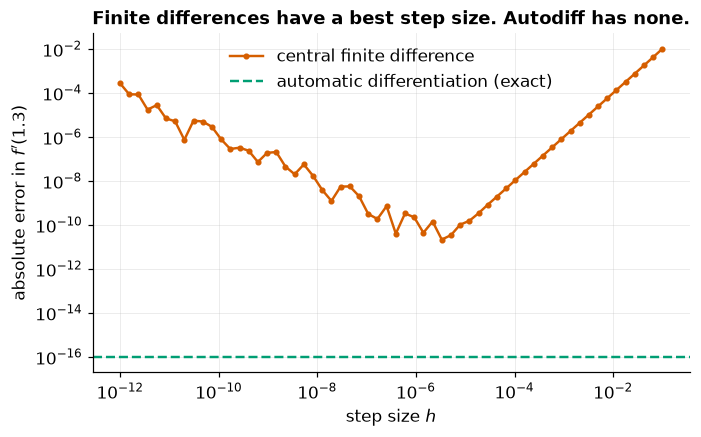

best FD error  : 2.12e-11 at h = 3.4e-06
FD error at h=1e-2  : 1.35e-04
FD error at h=1e-11 : 6.89e-06


In [6]:
def f(x):
    return torch.sin(x ** 2) + torch.cos(x ** 2)


x0 = torch.tensor(1.3, dtype=torch.float64)
steps = np.logspace(-12, -1, 60)

with torch.no_grad():
    fd = np.array([
        float((f(x0 + h) - f(x0 - h)) / (2 * h)) for h in steps
    ])

# float64 analytic value, so the comparison is about the method not the dtype
exact = float(2 * 1.3 * (np.cos(1.3 ** 2) - np.sin(1.3 ** 2)))
fd_err = np.abs(fd - exact)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(steps, fd_err, color=COLORS["ml"], marker="o", ms=3,
          label="central finite difference")
ax.axhline(1e-16, color=COLORS["hybrid"], ls="--",
           label="automatic differentiation (exact)")
ax.set_xlabel("step size $h$")
ax.set_ylabel("absolute error in $f'(1.3)$")
ax.set_title("Finite differences have a best step size. Autodiff has none.")
ax.legend()
plt.show()

print(f"best FD error  : {fd_err.min():.2e} at h = {steps[fd_err.argmin()]:.1e}")
print(f"FD error at h=1e-2  : {fd_err[np.argmin(abs(steps - 1e-2))]:.2e}")
print(f"FD error at h=1e-11 : {fd_err[np.argmin(abs(steps - 1e-11))]:.2e}")

The V is the whole story. Too large a step and you are measuring a chord, not a
tangent. Too small and catastrophic cancellation eats your answer. Even at the
bottom of the V, in *double* precision, finite differences give about eight good
digits against autodiff's sixteen.

This matters more than it looks. In §5 we'll find that a hydrologic model's
objective surface is not smooth — it has kinks where thresholds switch — and a
finite difference straddling a kink returns something that is not a derivative
of anything {cite}`kavetski2010ancient`.

## 3. Reverse mode — every partial derivative for the price of one

AD comes in two modes and the distinction is the reason any of this scales.

Suppose your model maps $n$ inputs to $m$ outputs.

**Forward mode** carries derivatives along with values as the program runs. One
forward pass gives you the derivative of *every* output with respect to *one*
input. To get all of them you run the program $n$ times.

**Reverse mode** runs the program once, saving intermediate values, then walks
the recording backwards. One backward pass gives you the derivative of *one*
output with respect to *every* input, for a cost of roughly two to three forward
passes.

Calibration has one output — a scalar loss — and many inputs. So reverse mode is
the right tool, and its cost is *independent of how many parameters you have*.
That single fact is why you can put a 19,208-weight LSTM inside a water balance
and still train it {cite}`lamichhane2025dynamic`, and why finite differences
cannot: as {cite}`shen2023differentiable` put it, 10,000 weights "would require
10,001 forward model evaluations."

Let's measure it. Same network shape, growing input dimension, so the parameter
count grows while the arithmetic per pass stays trivial.

In [7]:
rows = []
for n_in in [10, 100, 1000, 5000]:
    net = MLP(n_in=n_in, n_out=1, hidden=32, depth=2)
    xin = torch.randn(1, n_in)
    n_par = sum(p.numel() for p in net.parameters())

    with torch.no_grad():                       # forward only
        t0 = time.time()
        for _ in range(50):
            net(xin)
        t_fwd = (time.time() - t0) / 50

    t0 = time.time()                            # forward + one backward
    for _ in range(20):
        net.zero_grad()
        net(xin).backward()
    t_grad = (time.time() - t0) / 20

    rows.append((n_par, t_fwd, t_grad, (n_par + 1) * t_fwd))

print(f"{'parameters':>12}{'1 forward':>12}{'AD gradient':>14}{'FD gradient':>16}")
print("-" * 54)
for n_par, t_fwd, t_grad, t_fd in rows:
    print(f"{n_par:>12,}{t_fwd*1e3:>10.3f} ms{t_grad*1e3:>12.3f} ms{t_fd:>13.2f} s")

  parameters   1 forward   AD gradient     FD gradient
------------------------------------------------------
       1,441     0.064 ms       0.509 ms         0.09 s
       4,321     0.066 ms       0.372 ms         0.28 s
      33,121     0.038 ms       0.324 ms         1.26 s
     161,121     0.057 ms       0.434 ms         9.26 s


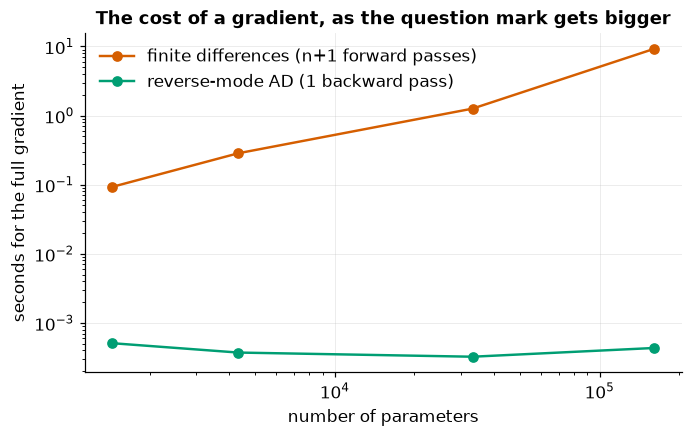

At 161,121 parameters, AD is 21,348x cheaper.


In [8]:
n_par = np.array([r[0] for r in rows], dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(n_par, [r[3] for r in rows], "o-", color=COLORS["ml"],
          label="finite differences (n+1 forward passes)")
ax.loglog(n_par, [r[2] for r in rows], "o-", color=COLORS["hybrid"],
          label="reverse-mode AD (1 backward pass)")
ax.set_xlabel("number of parameters")
ax.set_ylabel("seconds for the full gradient")
ax.set_title("The cost of a gradient, as the question mark gets bigger")
ax.legend()
plt.show()

print(f"At {rows[-1][0]:,} parameters, AD is {rows[-1][3]/rows[-1][2]:,.0f}x cheaper.")

The green line is flat because it is. Reverse mode does not care how many
parameters there are; it walks the same graph either way. The orange line has
slope one, and it is still only a *lower bound* on what finite differences would
cost, because it ignores the step-size problem from §2.

Two honest caveats, since this is the number people overclaim:

- Reverse mode costs **memory**. Everything needed for the backward pass has to
  be kept. Notebook `02_neural_odes_and_udes` measures that directly, and it is
  the reason the adjoint method exists.
- At six parameters none of this matters, and notebook 00 showed random search
  beating gradient descent outright. The argument is about scaling, not about
  constant factors.

## 4. A gradient through a hydrologic model

Now the thing that should actually persuade you. A scalar function is not a
model. Let's differentiate a water balance.

This is the same HBV-lite model as notebook 00 — one soil store feeding a fast
and a slow linear reservoir, six parameters $\boldsymbol{\theta}$ — restated
here so this notebook stands alone, with one addition: a `smooth` switch we'll
need in §5.

In the workshop's notation, $\mathbf{u} = (S_{\text{soil}}, S_{\text{fast}},
S_{\text{slow}})$ is the state, $\mathbf{x} = (P, \text{PET})$ the forcings, and
$f$ the known physics. There is no neural network anywhere in this section —
this is design **E** in the taxonomy of `resources/research_brief.md` §3, a
differentiable solver with no learned component at all.

In [9]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]


def simulate(P, E, theta, smooth=False, u0=(50., 5., 20.)):
    """HBV-lite. theta is (n_sets, 6); returns (n_sets, time) discharge in mm/d.

    Batched over the leading parameter dimension — the only loop is over time.
    `smooth=True` swaps the hard `min`/`clamp` for the differentiable
    surrogates in `workshop_utils`; §5 is about why you would want that.
    """
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n, dt = theta.shape[0], theta.dtype

    S_soil = torch.full((n,), u0[0], dtype=dt)
    S_fast = torch.full((n,), u0[1], dtype=dt)
    S_slow = torch.full((n,), u0[2], dtype=dt)
    zero, one = torch.zeros(n, dtype=dt), torch.ones(n, dtype=dt)

    discharge = []
    for t in range(P.shape[0]):
        if smooth:
            wetness = soft_clamp(S_soil / FC, zero, one, beta=10.0)
            et = E[t] * soft_clamp(S_soil / (LP * FC), zero, one, beta=10.0)
        else:
            wetness = torch.clamp(S_soil / FC, 0., 1.)
            et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)

        recharge = P[t] * wetness ** beta
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        # Percolation from the fast store to the slow one, capped at PERC.
        perc = (smooth_min(PERC * one, S_fast, beta=2.0) if smooth
                else torch.minimum(PERC * one, S_fast))

        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)

    return torch.stack(discharge, dim=1)


SPINUP = 365
ds = load_basin(BASIN_TEMPERATE)
split = split_by_water_year(ds, train=(1998, 1999), test=(2000, 2002),
                            spinup_days=SPINUP)


def arrays(d, dtype=torch.float32):
    return (torch.tensor(d.prcp.values, dtype=dtype),
            torch.tensor(d.pet.values, dtype=dtype),
            torch.tensor(d.qobs.values, dtype=dtype))


P, E, Q = arrays(split["train"], torch.float64)
print(f"{len(P)} days of forcing ({SPINUP} of them spin-up)")

1095 days of forcing (365 of them spin-up)


We're working in **float64** for this section. That is not how you would train —
float32 is faster and entirely adequate — but a gradient check in float32 is
limited to about six matching digits, and it is hard to tell "correct" from
"nearly correct" at six digits. In double precision the check is unambiguous.

Below is the calibrated parameter set from notebook 00. We ask for
$\partial\,\text{NSE}/\partial\boldsymbol{\theta}$ there, by autograd.

In [10]:
theta = torch.tensor([[198.6, 4.56, 0.90, 0.322, 0.028, 1.455]],
                     dtype=torch.float64, requires_grad=True)

t0 = time.time()
q = simulate(P, E, theta)[0]
score = nse(q[SPINUP:], Q[SPINUP:])
score.backward()
t_ad = time.time() - t0

grad_ad = theta.grad[0].clone()
print(f"NSE = {score.item():.4f}")
print(f"forward + backward through {len(P)} timesteps: {t_ad:.2f} s\n")
for name, g in zip(PARAM_NAMES, grad_ad.tolist()):
    print(f"  dNSE/d{name:<8} {g: .6e}")

NSE = 0.6354
forward + backward through 1095 timesteps: 0.77 s

  dNSE/dFC        2.726683e-05
  dNSE/dbeta      4.752189e-03
  dNSE/dLP       -2.320931e-02
  dNSE/dK_fast   -4.048722e-02
  dNSE/dK_slow   -2.080159e-02
  dNSE/dPERC      4.809638e-04


Six numbers. Do you believe them? There is exactly one way to find out.

In [11]:
with torch.no_grad():
    theta0 = theta.detach()
    h = theta0[0].abs() * 1e-6          # relative step, safely inside the V of §2

    # Build all 12 perturbed parameter sets at once and run them as one batch —
    # forward-only, so we never pay for a graph.
    perturbed = []
    for i in range(6):
        for sign in (+1, -1):
            t2 = theta0.clone()
            t2[0, i] += sign * h[i]
            perturbed.append(t2)

    t0 = time.time()
    sims = simulate(P, E, torch.cat(perturbed, 0))
    scores = torch.stack([nse(sims[k, SPINUP:], Q[SPINUP:]) for k in range(12)])
    t_fd = time.time() - t0

    grad_fd = torch.stack([(scores[2*i] - scores[2*i+1]) / (2 * h[i])
                           for i in range(6)])

print(f"{'':10}{'autograd':>16}{'finite diff':>16}{'rel. diff':>13}")
print("-" * 55)
for name, a, b in zip(PARAM_NAMES, grad_ad.tolist(), grad_fd.tolist()):
    print(f"{name:<10}{a:>16.8e}{b:>16.8e}{abs(a-b)/abs(b):>13.1e}")

print(f"\nautograd : 1 forward + 1 backward, {t_ad:.2f} s")
print(f"FD       : 12 extra simulations,   {t_fd:.2f} s (batched, no_grad)")

                  autograd     finite diff    rel. diff
-------------------------------------------------------
FC          2.72668340e-05  2.72668332e-05      2.9e-08
beta        4.75218863e-03  4.75218866e-03      7.7e-09
LP         -2.32093075e-02 -2.32093076e-02      2.4e-09
K_fast     -4.04872155e-02 -4.04872155e-02      2.2e-09
K_slow     -2.08015888e-02 -2.08015906e-02      8.7e-08
PERC        4.80963757e-04  4.80963799e-04      8.6e-08

autograd : 1 forward + 1 backward, 0.77 s
FD       : 12 extra simulations,   0.13 s (batched, no_grad)


Seven to eight matching digits on every parameter. The gradient is real, and the
two completely independent routes to it agree to the precision of the arithmetic.

That is the moment worth pausing on. You have not changed your model, your
forcings or your objective function. You have asked a question that derivative-
free calibration cannot ask — *which way should each parameter move, and by how
much* — and the answer came back exact.

Now the accounting. Finite differences needed 12 extra simulations for 6
parameters. Autograd needed one backward pass. At six parameters that is a bad
trade, and notebook 00 measured exactly how bad. But the FD column grows with
the number of parameters and the autograd column does not:

| Parameters | FD simulations needed | AD backward passes |
|---|---|---|
| 6 (HBV-lite) | 12 | 1 |
| 8 (SNOW-17, calibrated) | 16 | 1 |
| 19,208 (LSTM emitting SNOW-17 parameters) | 38,416 | 1 |

Since the gradient is in hand, it is worth looking at. Raw partials are in mixed
units — FC is in millimetres, `K_slow` is a rate — so scale each by the
parameter's own magnitude to get a dimensionless sensitivity.

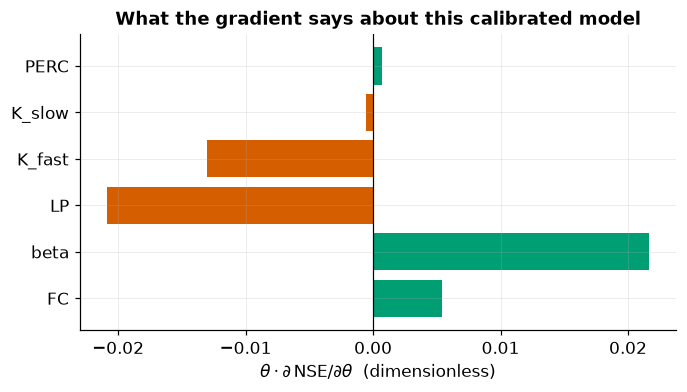

In [12]:
sensitivity = (grad_ad * theta.detach()[0]).numpy()

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = [COLORS["hybrid"] if s > 0 else COLORS["ml"] for s in sensitivity]
ax.barh(PARAM_NAMES, sensitivity, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(r"$\theta \cdot \partial\,\mathrm{NSE}/\partial\theta$  (dimensionless)")
ax.set_title("What the gradient says about this calibrated model")
plt.show()

`K_fast` and `LP` dominate; `FC` barely registers. Read that as a local
identifiability statement: at this point in parameter space, NSE has almost no
opinion about field capacity. You get that diagnostic for free every time you
take a gradient — no extra model runs, no sampling design. The same gradients
are reusable for sensitivity analysis, data assimilation and trajectory
optimization {cite}`shen2023differentiable`.

## 5. Where the gradient dies, and how to keep it alive

This section is the single most practical thing in the notebook. It is the
reason hybrid models fail to train, and the fix takes four lines.

Look again at `simulate`. It contains `torch.clamp` twice and `torch.minimum`
once. Every conceptual hydrologic model is full of these — a bucket spills when
it is full, percolation is capped, rain becomes snow below a threshold. Each one
is *piecewise* differentiable, which means autograd cheerfully returns a number
rather than raising an error. That is worse than an error
{cite}`shen2023differentiable`.

Start with the simplest case. Snowmelt is limited by how much snow there is:
`melt = min(potential_melt, SWE)`.

In [13]:
def melt_gradients(op, label):
    m_pot = torch.tensor(3.0, requires_grad=True)   # potential melt, mm/d
    swe = torch.tensor(5.0, requires_grad=True)     # snow on the ground, mm
    melt = op(m_pot, swe)
    melt.backward()
    print(f"{label:<28} melt = {melt.item():.3f} mm   "
          f"d(melt)/d(potential) = {m_pot.grad.item():.3f}   "
          f"d(melt)/d(SWE) = {swe.grad.item():.3f}")


melt_gradients(torch.minimum, "torch.minimum (hard)")
melt_gradients(lambda a, b: smooth_min(a, b, beta=1.0), "smooth_min (beta=1)")

torch.minimum (hard)         melt = 3.000 mm   d(melt)/d(potential) = 1.000   d(melt)/d(SWE) = 0.000
smooth_min (beta=1)          melt = 2.873 mm   d(melt)/d(potential) = 0.881   d(melt)/d(SWE) = 0.119


The hard minimum routes **all** of the gradient to the branch that happened to
win and **exactly zero** to the other one. As far as the optimizer is concerned,
the snowpack does not exist today. It cannot learn that a day with 5 mm of SWE
is any different from a day with 500 mm, because the derivative it sees is 0.000
either way.

`smooth_min` splits the gradient 0.88 / 0.12 instead of 1 / 0. Both branches now
report. The cost is honest and you should state it: the smooth minimum returns
2.873 mm where the true minimum is 3.000 — an approximation error of about
$\log 2/\beta$, which you control. `beta` is in the units of the quantities
being compared, so for fluxes in mm/day a `beta` of 5-20 keeps the error under a
tenth of a millimetre while keeping both gradients alive.

Thresholds are worse, because they kill the gradient on *both* branches.

In [14]:
temp = torch.tensor(0.0)

t_snow = torch.tensor(1.0, requires_grad=True)
snow_hard = 10.0 * (temp < t_snow).float()     # 10 mm of precip, all or nothing
print(f"hard threshold : snowfall = {snow_hard.item():.2f} mm, "
      f"d(snow)/d(t_snow) = {t_snow.grad}   <- no graph at all")

t_snow = torch.tensor(1.0, requires_grad=True)
snow_frac = smooth_threshold(-temp, center=-t_snow, sharpness=2.0)
snow_soft = 10.0 * snow_frac
snow_soft.backward()
print(f"smooth_threshold: snowfall = {snow_soft.item():.2f} mm, "
      f"d(snow)/d(t_snow) = {t_snow.grad.item():.3f}")

hard threshold : snowfall = 10.00 mm, d(snow)/d(t_snow) = None   <- no graph at all
smooth_threshold: snowfall = 8.81 mm, d(snow)/d(t_snow) = 2.100


A comparison operator produces a boolean; casting it to float produces a
constant. There is no graph, so `t_snow.grad` is `None`: the rain-snow threshold
temperature is *uncalibratable by gradient descent*, and nothing in the code
warns you.

`smooth_threshold` replaces the step with a sigmoid of controllable sharpness.
At 1 °C below the threshold it says "88% snow" rather than "100% snow", and it
reports a derivative of 2.1 mm per °C. {cite}`kalauni2025hybrid` replace every
discontinuous operation in the LaD model this way, with a steepness parameter of
20, and this is the standard move.

:::{admonition} Why this matters for hydrology
:class: note
Hydrologists have been writing smooth relaxations for decades without calling
them that. SNOW-17 partitions precipitation with a *linear ramp* between
`PXTEMP1` and `PXTEMP2` rather than a single threshold
{cite}`anderson2006snow17`, and the "ancient numerical daemons" papers
{cite}`clark2010ancient, kavetski2010ancient` argued for smoothing thresholds on
the grounds that discontinuities wreck the objective surface for *derivative-free*
calibration too. The differentiability requirement is new; the fix is not.
:::

### The same problem, inside the model

Scalar demos are clean. Does it bite in practice? `PERC` in our model caps
percolation at `min(PERC, S_fast)`. Let's map NSE as a function of `PERC` alone,
holding the other five parameters at their calibrated values.

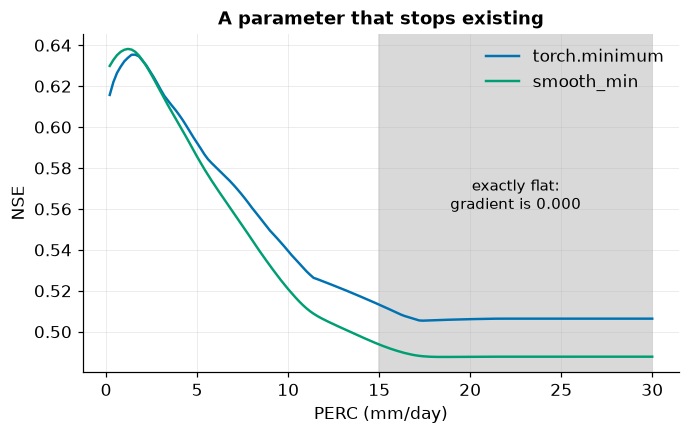

In [15]:
perc_grid = torch.linspace(0.2, 30.0, 150, dtype=torch.float64)
base = torch.tensor([198.6, 4.56, 0.90, 0.322, 0.028, 1.455], dtype=torch.float64)

with torch.no_grad():
    grid = base.repeat(len(perc_grid), 1)
    grid[:, 5] = perc_grid
    curves = {}
    for label, smooth in [("hard min", False), ("smooth_min", True)]:
        sims = simulate(P, E, grid, smooth=smooth)
        curves[label] = torch.stack(
            [nse(sims[k, SPINUP:], Q[SPINUP:]) for k in range(len(perc_grid))]
        ).numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(perc_grid, curves["hard min"], color=COLORS["physics"], label="torch.minimum")
ax.plot(perc_grid, curves["smooth_min"], color=COLORS["hybrid"], label="smooth_min")
ax.axvspan(15, 30, color="0.85", zorder=0)
ax.text(22.5, 0.56, "exactly flat:\ngradient is 0.000", ha="center", fontsize=10)
ax.set_xlabel("PERC (mm/day)")
ax.set_ylabel("NSE")
ax.set_title("A parameter that stops existing")
ax.legend(loc="upper right")
plt.show()

In [16]:
for perc in [1.455, 10.0, 30.0]:
    th = base.clone().unsqueeze(0)
    th[0, 5] = perc
    th.requires_grad_(True)
    s = nse(simulate(P, E, th)[0][SPINUP:], Q[SPINUP:])
    s.backward()
    print(f"PERC = {perc:6.2f} mm/d :  NSE = {s.item():.4f},  "
          f"dNSE/dPERC = {th.grad[0, 5].item(): .3e}")

# How many days does the cap actually bind at the calibrated value?
with torch.no_grad():
    th = base.clone().unsqueeze(0)
    FC, beta, LP, K_fast, K_slow, PERC = th.T
    S_soil, S_fast, S_slow = (torch.tensor([50.], dtype=torch.float64),
                              torch.tensor([5.], dtype=torch.float64),
                              torch.tensor([20.], dtype=torch.float64))
    inactive = 0
    for t in range(len(P)):
        w = torch.clamp(S_soil / FC, 0., 1.)
        rech = P[t] * w ** beta
        S_soil = torch.clamp(S_soil + P[t] - rech - E[t] * torch.clamp(S_soil/(LP*FC), 0., 1.), min=0.)
        inactive += int(S_fast.item() < PERC.item())
        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + rech - perc
        S_fast = S_fast - K_fast * S_fast
        S_slow = S_slow + perc
        S_slow = S_slow - K_slow * S_slow

print(f"\nDays on which S_fast < PERC, so PERC contributes nothing to the gradient: "
      f"{inactive} of {len(P)} ({100*inactive/len(P):.0f}%)")

PERC =   1.46 mm/d :  NSE = 0.6354,  dNSE/dPERC =  4.810e-04


PERC =  10.00 mm/d :  NSE = 0.5394,  dNSE/dPERC = -1.062e-02


PERC =  30.00 mm/d :  NSE = 0.5064,  dNSE/dPERC =  0.000e+00

Days on which S_fast < PERC, so PERC contributes nothing to the gradient: 854 of 1095 (78%)


Above about 15 mm/day the fast store never reaches the cap, the minimum always
selects the other branch, and `dNSE/dPERC` is **exactly 0.0**. An optimizer
started there will leave `PERC` where it is forever and report convergence. And
even at the calibrated value, 78% of days contribute nothing at all — the
gradient you are descending is built from the other 22%.

Be honest about the limits of the fix, though. Smoothing recovers signal *within
the smoothing width*. It will not resurrect a parameter sitting ten times outside
the active range: at `PERC = 30` the smooth version's gradient is also
indistinguishable from zero. The real protection against that is the other half
of the recipe — squash parameters onto sensible physical ranges with `ParamMap`
so the model never starts somewhere absurd {cite}`lamichhane2025dynamic`.

Notice too that the green curve is not the blue one. Smoothing changes your
model, slightly. Say so in your paper.

### The replacements worth memorizing

| In your model | Replace with | Why |
|---|---|---|
| `min(a, b)` | `smooth_min(a, b, beta)` | both branches keep a gradient |
| `max(a, b)` | `smooth_max(a, b, beta)` | same |
| `clamp(x, lo, hi)` | `soft_clamp(x, lo, hi, beta)` | nonzero gradient at the ceiling |
| `relu(x)`, `max(x, 0)` | `smooth_relu(x)` (softplus) | keeps stores non-negative smoothly |
| `if T < T_s: snow` | `smooth_threshold(-T, -T_s, k)` | a step function has no gradient |

:::{admonition} Gotcha — two PyTorch-specific traps
:class: warning
**`torch.where` propagates NaN from the branch you didn't take.** If the untaken
branch computes `sqrt` of a negative number or divides by zero, its gradient is
`NaN` and `torch.where` will happily add it in. Mask the *input*, not the output.

**In-place writes into a tensor that needs grad break the graph.** `u[t] = ...`
either raises a version-counter error or silently detaches. Accumulate into a
Python list and `torch.stack` at the end — which is what `simulate` does above,
and why.
:::

## Your turn

Five minutes. Both are small edits to code already in this notebook.

1. **Find another dead gradient.** `soft_clamp` appears twice in `simulate`, on
   `wetness` and on the ET reduction. Pick `LP` and repeat the §5 experiment:
   map NSE against `LP` over its full range 0.3-1.0 with hard and smooth ops, and
   take `dNSE/dLP` at a few points. Is there a flat region? Is it as bad as
   `PERC`'s?

2. **Tune the smoothing.** Rerun the `melt_gradients` comparison with
   `beta = 0.2`, `1`, `5` and `50`. Tabulate the returned melt and the two
   partial derivatives. What is the trade-off, and where would you set `beta`
   for fluxes measured in mm/day?

:::{dropdown} Solution — what you should see

**1.** `LP` is far better behaved than `PERC`. The ET reduction term
`clamp(S_soil/(LP*FC), 0, 1)` saturates on wet days and not on dry ones, so at
any `LP` a decent fraction of days sit on the sloping branch and the gradient is
nonzero everywhere in range. The NSE-vs-`LP` curve does flatten near `LP = 0.3`,
where the threshold `LP*FC` is low enough that almost every day saturates.

```python
lp_grid = torch.linspace(0.3, 1.0, 80, dtype=torch.float64)
grid = base.repeat(len(lp_grid), 1)
grid[:, 2] = lp_grid
with torch.no_grad():
    sims = simulate(P, E, grid)
    curve = torch.stack([nse(sims[k, SPINUP:], Q[SPINUP:]) for k in range(len(lp_grid))])
plt.plot(lp_grid, curve); plt.xlabel("LP"); plt.ylabel("NSE"); plt.show()
```

The lesson generalizes: a threshold hurts most when the model spends most of its
time on one side of it. Check the *occupancy* of each branch, not just the code.

**2.** Larger `beta` means a more accurate minimum and a more lopsided gradient
split:

| `beta` | smooth min of (3, 5) | d/d(potential) | d/d(SWE) |
|---|---|---|---|
| 0.2 | 2.31 | 0.60 | 0.40 |
| 1 | 2.87 | 0.88 | 0.12 |
| 5 | 3.00 | 1.00 | 0.00005 |
| 50 | 3.00 | 1.00 | ~1e-43 |

At `beta = 50` you have reimplemented `torch.minimum`, including its dead branch.
At `beta = 0.2` the "minimum" of 3 and 5 is 2.31, which is not a minimum. For
fluxes in mm/day, 5-20 is the useful range — error under 0.15 mm, gradients still
alive. This is a modeling choice you should report, not a hidden constant.
:::

## Takeaways

- Automatic differentiation is neither symbolic differentiation nor finite
  differences: it records the operations your code actually executed and applies
  the chain rule to that record, returning a derivative exact to floating-point
  precision with no step size to choose.
- A gradient through a 1,095-step hydrologic simulation agrees with finite
  differences to **seven or eight digits** in double precision. You can check this for your own model
  in about ten lines, and you should, before you trust it.
- Reverse mode returns *all* partial derivatives per backward pass, at a cost
  independent of the parameter count. That, not raw speed, is why a
  19,208-weight network inside a water balance is trainable.
- `min`, `max`, `clamp` and threshold comparisons return **exactly zero**
  gradient on the branch they didn't take, and a boolean comparison returns no
  gradient at all. In our model, 78% of days contributed nothing to
  `dNSE/dPERC`, and above 15 mm/day the parameter was invisible to the optimizer
  entirely.
- The smooth surrogates in `workshop_utils` fix this for the price of a small,
  controllable approximation error — but they cannot rescue a parameter that is
  far outside its active range, so constrain parameters to physical bounds as
  well.

## Where next

`02_neural_odes_and_udes` takes the same machinery to the continuous limit: what
it means to differentiate through an ODE *solver*, why the adjoint method exists,
and the universal differential equation as the frame that ties every hybrid model
in this workshop together.

## References

```{bibliography}
:filter: docname in docnames
```